In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt 
from pathlib import Path
from PIL import Image
from IPython.display import display, Image
from pypcd4 import PointCloud as PC

from preprocessing.preprocessing_lidar import PreprocessingLidar
from preprocessing.config import GlobalConfig

ModuleNotFoundError: No module named 'preprocessing'

In [2]:
def run(file):    
    config = GlobalConfig()
    os.environ["CUDA_DEVICE_ORDER"] = "PCI_BUS_ID" 
    os.environ["CUDA_VISIBLE_DEVICES"] = config.gpu_id
    config.datadir = "experiment"
    
    preproc_lidar = PreprocessingLidar(config)

    route = Path("experiment")
    dir_lidseg = route / "lidar" / "seg"
    # visualisasi
    dir_lidseg_bev = route / "lidar" / "img" / "bev_seg"
    dir_lidseg_fro = route / "lidar" / "img" / "front_seg"
    dir_lidseg_rea = route / "lidar" / "img" / "rear_seg"
    dir_liddep_bev = route / "lidar" / "img" / "bev_dep"
    dir_liddep_fro = route / "lidar" / "img" / "front_dep"
    dir_liddep_rea = route / "lidar" / "img" / "rear_dep"
    dir_lidseg.mkdir(parents=True, exist_ok=True)
    dir_lidseg_bev.mkdir(parents=True, exist_ok=True)
    dir_lidseg_fro.mkdir(parents=True, exist_ok=True)
    dir_lidseg_rea.mkdir(parents=True, exist_ok=True)
    dir_liddep_bev.mkdir(parents=True, exist_ok=True)
    dir_liddep_fro.mkdir(parents=True, exist_ok=True)
    dir_liddep_rea.mkdir(parents=True, exist_ok=True)

    preproc_lidar.paths = {
        'seg': dir_lidseg / f"{file}.npy",
        'bev_seg': dir_lidseg_bev / f"{file}.png",
        'bev_dep': dir_liddep_bev / f"{file}.png",
        'front_seg': dir_lidseg_fro / f"{file}.png",
        'front_dep': dir_liddep_fro / f"{file}.png",
        'rear_seg': dir_lidseg_rea / f"{file}.png",
        'rear_dep': dir_liddep_rea / f"{file}.png"
    }
    preproc_lidar.set_input(f"{file}")
    preproc_lidar.process()
    return preproc_lidar.get_output(as_image=True, to_file=False)

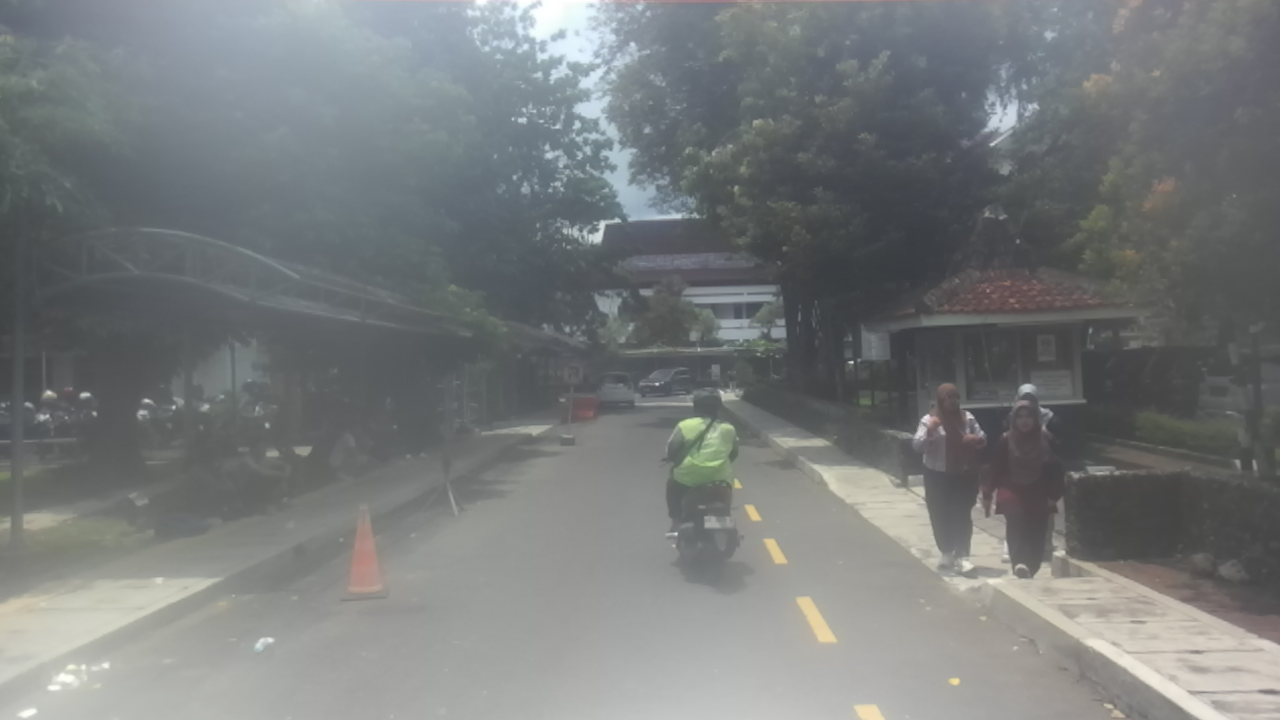

In [4]:
display(Image(filename='experiment/1762315692_0400489741.png'))

PointCloud(fields=('x', 'y', 'z', 'intensity') size=(4, 4, 4, 4) type=('F', 'F', 'F', 'F') count=(1, 1, 1, 1) points=57600 width=57600 height=1 version='0.7' viewpoint=(0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0) data=<Encoding.BINARY_COMPRESSED: 'binary_compressed'>)
LEEEEENGTH: 47318


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].


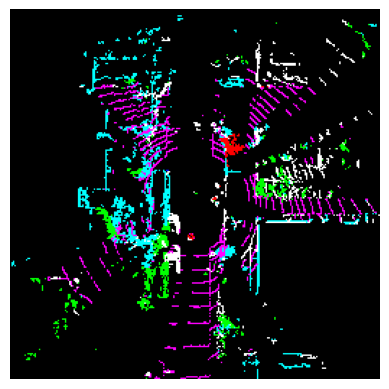

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..253.3813].


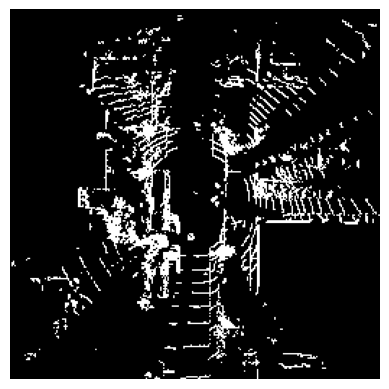

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].


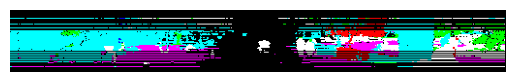

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-159.61324..252.17395].


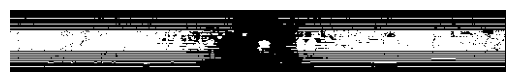

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].


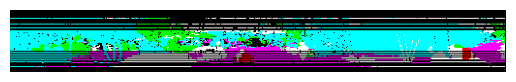

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-313.80765..220.74141].


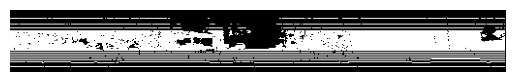

In [5]:
path = "experiment/1762315692_0400489741_without_nan_clean.pcd"
pcd = PC.from_path(f"{path}")
print(pcd)
images = run(path)
for i in range(0, 6):
    plt.imshow(images[i])
    plt.axis('off')
    plt.show()

PointCloud(fields=('x', 'y', 'z', 'intensity') size=(4, 4, 4, 4) type=('F', 'F', 'F', 'F') count=(1, 1, 1, 1) points=47318 width=47318 height=1 version='0.7' viewpoint=(0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0) data=<Encoding.BINARY_COMPRESSED: 'binary_compressed'>)


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].


LEEEEENGTH: 47318


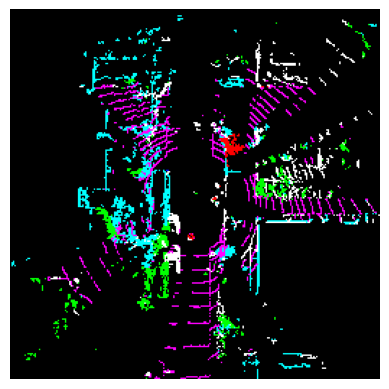

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..253.34753].


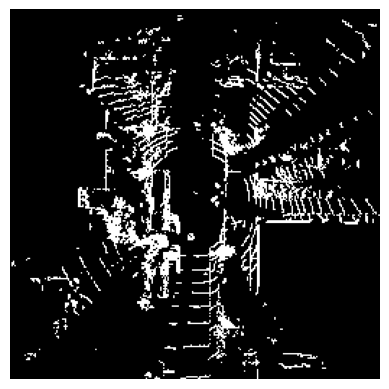

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].


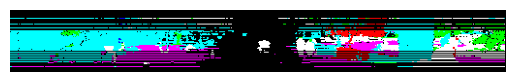

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-158.48117..252.17395].


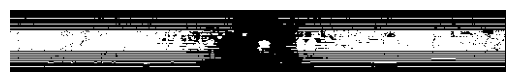

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].


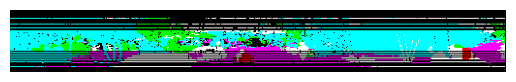

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-313.80765..220.74141].


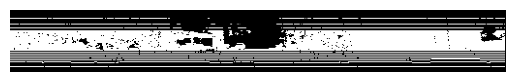

In [6]:
path = "experiment/1762315692_0400489741.pcd"
pcd = PC.from_path(f"{path}")
print(pcd)
images = run(path)
for i in range(0, 6):
    plt.imshow(images[i])
    plt.axis('off')
    plt.show()